# CentraleSupelec - Natural language processing
# Practical session n°7

## Natural Language Inferencing (NLI): 

(NLI) is a classical NLP (Natural Language Processing) problem that involves taking two sentences (the premise and the hypothesis ), and deciding how they are related (if the premise *entails* the hypothesis, *contradicts* it, or *neither*).

Ex: 


| Premise | Label | Hypothesis |
| --- | --- | --- |
| A man inspects the uniform of a figure in some East Asian country. | contradiction | The man is sleeping. |
| An older and younger man smiling. | neutral | Two men are smiling and laughing at the cats playing on the floor. |
| A soccer game with multiple males playing. | entailment | Some men are playing a sport. |

### Stanford NLI (SNLI) corpus

In this labwork, I propose to use the Stanford NLI (SNLI) corpus ( https://nlp.stanford.edu/projects/snli/ ), available in the *Datasets* library by Huggingface.

    from datasets import load_dataset
    snli = load_dataset("snli")
    #Removing sentence pairs with no label (-1)
    snli = snli.filter(lambda example: example['label'] != -1) 

## Subject

You are asked to provide an operational Jupyter notebook that performs the task of NLI. For that, you need to tackle the following aspects of the problem:

1. Loading and preprocessing the data
2. Designing a PyTorch model that, given two sentences, decides how they are related (*entails*, *contradicts* or *neither*.)
3. Training and evaluating the model using appropriate metrics
4. (Optional) Allowing to play with the model (forward user sentences and visualize the prediction easily)
5. (Optional) Providing visual insight about the model (i.e. visualizing the attention if your model is using attention)

You can choose between a trained approach (for which I suggest using the huggingface *transformer* library) or a zero-shot or few-shot approach (for which I suggest using a local *ollama* server). You can, of course, do both and compare your results.

## Evaluation

The evaluation will be based on several criteria:

- Clarity and readability of the notebook. The notebook is the report of you project. Make it easy and pleasant to read.
- Justification of implementation choices (i.e. the network, the cost funtion, the optimizer, ...)
- Quality of the code. The various deeplearning and NLP labworks provide many example of good practices for designing experiments with neural networks. Use them as inspirational examples!

## Additional recommendations

- You are not seeking to publish a research paper! I'm not expecting state-of-the-art results! The idea of this labwork is to assess that you have integrated the skills necessary to handle textual data using deep neural network techniques.

- This labwork will be evaluated but we are still here to help you! Don't hesitate to request our help if you are stuck.

- If you intend to use BERT based models, let me give you an advice. The bert-base-* models available in *Transformers* need more than 12Go to be fine-tuned on GPU. To avoid memory issues, you can use several solutions: 

    - Use a lighter BERT based model such as DistilBERT, ALBERT, ...
    - Train a classification model on top of BERT, whithout fine-tuning it (i.e. freezing BERT weights)

## Huggingface documentations

In case you want to use the huggingface *Datasets* and *Transformer* libraries (which I advice), here are some useful documentation pages:

- Dataset quick tour

    https://huggingface.co/docs/datasets/quicktour.html
    
- Documentation on data preprocessing for transformers

    https://huggingface.co/transformers/preprocessing.html
    
- Transformer Quick tour (with distilbert example for classification).

    https://huggingface.co/transformers/quicktour.html
    



#### IMPORTS

In [1]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding, AutoModel, get_linear_schedule_with_warmup
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import tqdm
import re
import time
from litellm import completion

#### Load Dataset

In [2]:
# Chargement du dataset SNLI depuis HuggingFace
snli = load_dataset("snli")
# Suppression des paires sans label (label = -1)
snli = snli.filter(lambda example: example["label"] != -1)

snli


# Dataset plus petit pour faire des tests :
N_TRAIN = 10000
N_VAL = 1000
N_TEST = 1000

snli_small = {
    "train": snli["train"].shuffle(seed=42).select(range(min(N_TRAIN, len(snli["train"])))),
    "validation": snli["validation"].shuffle(seed=42).select(range(min(N_VAL, len(snli["validation"])))),
    "test": snli["test"].shuffle(seed=42).select(range(min(N_TEST, len(snli["test"])))),
}

snli_small


dataset_to_use = snli

#### Choose model and tokenizer

In [3]:
bert_model = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(bert_model)

#### Préprocessing : labels et aperçu des données

In [5]:
# Labels names
id2label = {0: "entailment", 1: "neutral", 2: "contradiction"}
label2id = {v: k for k, v in id2label.items()}


# an example
ex = snli_small["train"][0]
print("Premise    :", ex["premise"])
print("Hypothesis :", ex["hypothesis"])
print("Label      :", id2label[ex["label"]])

Premise    : A group of people riding a yellow roller coaster.
Hypothesis : A group of people are riding a roller coaster.
Label      : entailment


#### Tokenisation des paires (premise, hypothesis)

In [6]:
def preprocess_function(batch):
    return tokenizer(
        batch["premise"],
        batch["hypothesis"],
        truncation=True,
        max_length=128,
    )

tokenized_train = dataset_to_use["train"].map(preprocess_function, batched=True)
tokenized_val = dataset_to_use["validation"].map(preprocess_function, batched=True)
tokenized_test = dataset_to_use["test"].map(preprocess_function, batched=True)

# Colonne attendue pour la loss PyTorch
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_val = tokenized_val.rename_column("label", "labels")
tokenized_test = tokenized_test.rename_column("label", "labels")

# On garde uniquement les entrées du modèle + labels
cols_to_remove = ["premise", "hypothesis"]
tokenized_train = tokenized_train.remove_columns(cols_to_remove)
tokenized_val = tokenized_val.remove_columns(cols_to_remove)
tokenized_test = tokenized_test.remove_columns(cols_to_remove)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(tokenized_train)
print(tokenized_val)
print(tokenized_test)

Map:   0%|          | 0/9842 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 549367
})
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 9842
})
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 9824
})


#### Analyse de données

In [ ]:
# Regardons la plus longue séquence de tokens
def get_max_length(dataset):
    return max(len(x["input_ids"]) for x in dataset)


print(get_max_length(tokenized_train))
print(get_max_length(tokenized_val))
print(get_max_length(tokenized_test))

# La séquence la plus longue est de 125 tokens (sur tout snli) -- pas de soucis sur la truncation


125
113
76


#### Encodeur Hugging Face + tête de classification faite main

- J'ai voulu remplacer la simple couche de classification que l'on pourrait ajouter au BERT car d'xpéreince on a un entrinament menant à de meilleurs perfs qu'une simple couche de classification

In [7]:
class CustomClassif(nn.Module):
    def __init__(self, encoder_name, num_labels=3, dropout=0.2):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(encoder_name)
        hidden_size = self.encoder.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_labels),
        )

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_repr = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls_repr)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
        return {"loss": loss, "logits": logits}


def evaluate_model(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            out = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["labels"],
            )
            total_loss += out["loss"].item()
            preds = torch.argmax(out["logits"], dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())

    return {
        "loss": total_loss / max(len(dataloader), 1),
        "accuracy": accuracy_score(all_labels, all_preds),
        "f1_macro": f1_score(all_labels, all_preds, average="macro"),
        "y_true": np.array(all_labels),
        "y_pred": np.array(all_preds),
    }

#### Boucle d'entrainement

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CustomClassif(encoder_name=bert_model, num_labels=3).to(device)


# The Dataloaders
train_loader = DataLoader(tokenized_train, batch_size=16, shuffle=True, collate_fn=data_collator)
val_loader = DataLoader(tokenized_val, batch_size=32, shuffle=False, collate_fn=data_collator)
test_loader = DataLoader(tokenized_test, batch_size=32, shuffle=False, collate_fn=data_collator)


optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
num_epochs = 1
num_training_steps = num_epochs * len(train_loader)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),
    num_training_steps=num_training_steps,
)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for batch in tqdm.tqdm(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"],
        )
        loss = out["loss"]

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    val_metrics = evaluate_model(model, val_loader, device)

    print(f"Epoch {epoch + 1}/{num_epochs}")
    print(f"Train loss: {train_loss:.4f}")
    print(f"Val loss: {val_metrics['loss']:.4f}")
    print(f"Val accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Val f1_macro: {val_metrics['f1_macro']:.4f}\n")

100%|██████████| 34336/34336 [27:27<00:00, 20.84it/s]


Epoch 1/1
Train loss: 0.4068
Val loss: 0.2733
Val accuracy: 0.9004
Val f1_macro: 0.9002



#### Évaluation finale : test set, rapport de classification et matrice de confusion

- J'ai en dernière instance fait un test avec bert-base-uncased car j'avais la puissance nécessaire sur le dce.
- Avec DistilBert j'obtenais 0.82 pour le même entrainement

Accuracy test: 0.9009568403908795
F1 macro test: 0.9006261503015779

Classification report:
               precision    recall  f1-score   support

   entailment       0.91      0.91      0.91      3368
      neutral       0.88      0.86      0.87      3219
contradiction       0.92      0.93      0.92      3237

     accuracy                           0.90      9824
    macro avg       0.90      0.90      0.90      9824
 weighted avg       0.90      0.90      0.90      9824



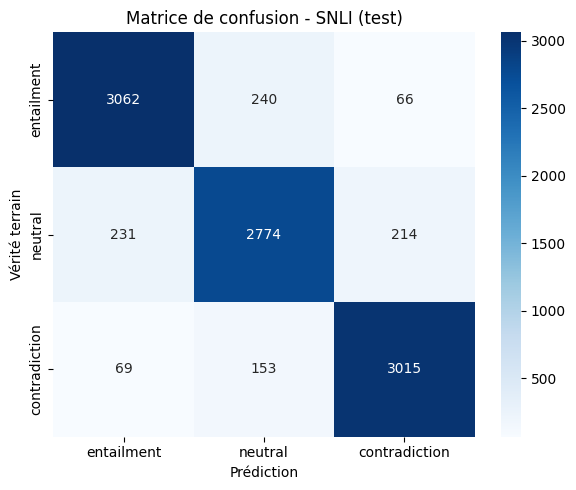

In [10]:
test_metrics = evaluate_model(model, test_loader, device)
y_true = test_metrics["y_true"]
y_pred = test_metrics["y_pred"]

print("Accuracy test:", test_metrics["accuracy"])
print("F1 macro test:", test_metrics["f1_macro"])
print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=[id2label[i] for i in range(3)]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[id2label[i] for i in range(3)],
    yticklabels=[id2label[i] for i in range(3)],
)
plt.title("Matrice de confusion - SNLI (test)")
plt.xlabel("Prédiction")
plt.ylabel("Vérité terrain")
plt.tight_layout()
plt.show()


#### Test zéro-shot de ce problème via un LLM chargé sur ollama. 
 - on commence par faire du prompt-tuning pour un modèle donné - ici gemma3:12b sur le trainSet sans toucher au validation set.
 - enfin on plotera les résultats réalisé sur le validation set

In [3]:
# model name and api url
OLLAMA_MODEL = "ollama/gemma3:12b"
OLLAMA_API_BASE = "http://localhost:11434"
temp_reco = 1.0

RANDOM_SEED_OLLAMA = 42

# idnice d'erreur de parsing
PARSE_FAIL_ID = 3

NLI_LABELS_ORDER = ("entailment", "neutral", "contradiction")
LABEL_TO_ID = {name: i for i, name in enumerate(NLI_LABELS_ORDER)}

# explication des règles
rules_text = """
You are given a premise and a hypothesis. Your task is to determine the relationship between the premise and the hypothesis.
As a response, you must choose exactly one label:

- entailment: the hypothesis must be true if the premise is true.
- contradiction: the hypothesis cannot be true if the premise is true.
- neutral: neither of the above.

Answer with a single word only: entailment, neutral, or contradiction."""


system_prompt = """Your response must be a single word only and nothing else to make the parsing easier."""




def build_nli_messages(premise: str, hypothesis: str, system_prompt: str | None = None):
    user_text = f"Premise: {premise}\nHypothesis: {hypothesis}\n{rules_text}\n" + rules_text
    messages = []
    if system_prompt:
        messages.append({"role": "system", "content": system_prompt})
    messages.append({"role": "user", "content": user_text})
    return messages


def parse_response(raw: str):
    if raw is None or not str(raw).strip():
        return PARSE_FAIL_ID, "empty"
    text = str(raw).strip().lower()
    for label in NLI_LABELS_ORDER:
        if re.search(rf"\b{re.escape(label)}\b", text):
            return LABEL_TO_ID[label], None
    return PARSE_FAIL_ID, "unparsed"


def call_ollama(premise, hypothesis, system_prompt=None, temperature=temp_reco, max_retries=2):
    messages = build_nli_messages(premise, hypothesis, system_prompt)
    last_err = None
    for attempt in range(max_retries + 1):
        try:
            resp = completion(
                model=OLLAMA_MODEL,
                messages=messages,
                api_base=OLLAMA_API_BASE,
                temperature=temperature,
                stream=False,
            )
            content = resp.choices[0].message.content
            pred_id, meta = parse_response(content)
            return pred_id, content, meta
        except Exception as e:
            last_err = e
            time.sleep(1.5 * (attempt + 1))
    return PARSE_FAIL_ID, "", f"api_error: {last_err}"


In [7]:
rng = np.random.default_rng(RANDOM_SEED_OLLAMA)
train_ds = dataset_to_use["train"]
k_preview = 10
idx_train = rng.choice(len(train_ds), size=k_preview, replace=False)

for i in idx_train:
    ex = train_ds[int(i)]
    p, h = ex["premise"], ex["hypothesis"]
    gold = int(ex["label"])
    pred_id, raw, meta = call_ollama(p, h, system_prompt=system_prompt)
    print("---")
    print("gold    :", id2label[gold])
    print(
        "pred    :",
        id2label[pred_id] if pred_id != PARSE_FAIL_ID else f"PARSE_FAIL ({meta})",
    )
    print("raw     :", (raw or "")[:300].replace("\n", " "))


---
gold    : contradiction
pred    : neutral
raw     : Neutral
---
gold    : contradiction
pred    : neutral
raw     : Neutral
---
gold    : contradiction
pred    : neutral
raw     : Neutral
---
gold    : neutral
pred    : entailment
raw     : entailment
---
gold    : neutral
pred    : entailment
raw     : entailment
---
gold    : entailment
pred    : entailment
raw     : entailment
---
gold    : contradiction
pred    : neutral
raw     : Neutral
---
gold    : neutral
pred    : neutral
raw     : Neutral
---
gold    : neutral
pred    : neutral
raw     : Neutral
---
gold    : entailment
pred    : entailment
raw     : entailment


#### Après avoir constaté que le parsing fonctionnait on peut lancer l'évaluation sur le validation set

Samples évalués: 300
Échecs parse/API : 0 (0.0%)
Accuracy (global): 0.6300
Accuracy (sans parse fail): 0.6300
F1 macro (sans parse fail): 0.5870


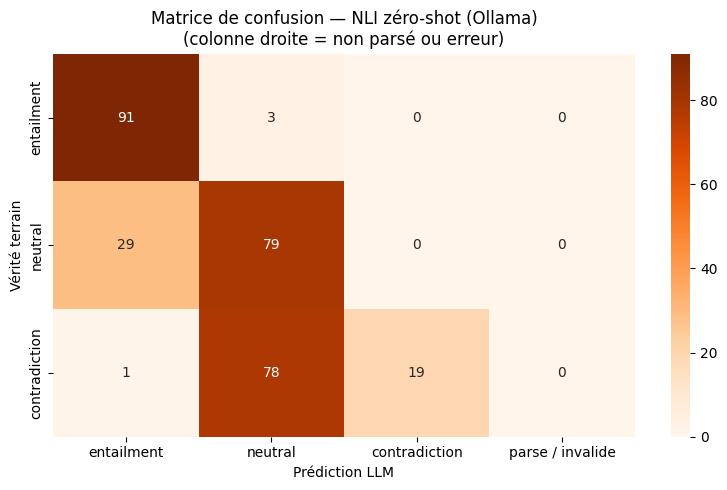

In [9]:
N_VAL_SAMPLES = 300

# Évaluation zéro-shot Ollama
val_ds = dataset_to_use["validation"]
rng = np.random.default_rng(RANDOM_SEED_OLLAMA)

n_eval = min(N_VAL_SAMPLES, len(val_ds))
idx_eval = rng.choice(len(val_ds), size=n_eval, replace=False)

y_true_ollama = []
y_pred_ollama = []
parse_debug = []

for i in idx_eval:
    ex = val_ds[int(i)]
    gold = int(ex["label"])
    pred_id, raw, meta = call_ollama(ex["premise"], ex["hypothesis"], system_prompt=system_prompt)

    y_true_ollama.append(gold)
    y_pred_ollama.append(pred_id)
    parse_debug.append({"raw": raw, "meta": meta})

n_tot = len(y_pred_ollama)
n_fail = sum(p == PARSE_FAIL_ID for p in y_pred_ollama)

print(f"Samples évalués: {n_tot}")
print(f"Échecs parse/API : {n_fail} ({(100 * n_fail / n_tot if n_tot else 0):.1f}%)")

# Métriques globales
acc_all = accuracy_score(y_true_ollama, y_pred_ollama)
print(f"Accuracy (global): {acc_all:.4f}")

# Métriques sur prédictions valides uniquement (sans PARSE_FAIL)
valid_idx = [i for i, p in enumerate(y_pred_ollama) if p != PARSE_FAIL_ID]
y_true_valid = [y_true_ollama[i] for i in valid_idx]
y_pred_valid = [y_pred_ollama[i] for i in valid_idx]

if y_true_valid:
    acc_valid = accuracy_score(y_true_valid, y_pred_valid)
    f1_macro_valid = f1_score(
        y_true_valid,
        y_pred_valid,
        average="macro",
        labels=[0, 1, 2],
        zero_division=0,
    )
    print(f"Accuracy (sans parse fail): {acc_valid:.4f}")
    print(f"F1 macro (sans parse fail): {f1_macro_valid:.4f}")
else:
    print("Accuracy (sans parse fail): N/A")
    print("F1 macro (sans parse fail): N/A")

# Matrice de confusion
pred_labels_cm = [0, 1, 2, PARSE_FAIL_ID]
cm_ollama = confusion_matrix(y_true_ollama, y_pred_ollama, labels=pred_labels_cm)

col_names = [id2label[i] for i in range(3)] + ["parse / invalide"]
row_names = [id2label[i] for i in range(3)]
cm_display = cm_ollama[:3, :]

plt.figure(figsize=(8, 5))
sns.heatmap(
    cm_display,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=col_names,
    yticklabels=row_names,
)
plt.title("Matrice de confusion — NLI zéro-shot (Ollama)\n(colonne droite = non parsé ou erreur)")
plt.xlabel("Prédiction LLM")
plt.ylabel("Vérité terrain")
plt.tight_layout()
plt.show()

# Quelques échecs de parsing pour déboguer le prompt
if n_fail:
    print("\nExemples d'échecs de parsing (max 5):")
    shown = 0
    for i in range(n_tot):
        if y_pred_ollama[i] != PARSE_FAIL_ID:
            continue
        print("---")
        print("gold:", id2label[y_true_ollama[i]])
        print("meta:", parse_debug[i]["meta"])
        print("raw :", (parse_debug[i]["raw"] or "")[:400].replace("\n", " "))
        shown += 1
        if shown >= 5:
            break


#### Few-shot NLI avec Ollama
- ON crée un fichier .txt avec des exemple tirés du dataset de test afin d'améliorer les performances de notre modèle


In [6]:
N_SHOTS_PER_LABEL = 10

rng_shots = np.random.default_rng(RANDOM_SEED_OLLAMA)
train_ds = dataset_to_use["train"]

# Séparer les indices par label
indices_by_label = {label_id: [] for label_id in id2label}
for i, ex in enumerate(train_ds):
    indices_by_label[ex["label"]].append(i)

# Tirer N_SHOTS_PER_LABEL exemples par classe
few_shot_lines = []
for label_id, label_name in id2label.items():
    chosen = rng_shots.choice(indices_by_label[label_id], size=N_SHOTS_PER_LABEL, replace=False)
    for idx in chosen:
        ex = train_ds[int(idx)]
        few_shot_lines.append(
            f"Premise: {ex['premise']}\nHypothesis: {ex['hypothesis']}\nLabel: {label_name}"
        )

# Mélanger pour ne pas regrouper par classe
rng_shots.shuffle(few_shot_lines)

few_shot_content = "\n\n".join(few_shot_lines)

with open("few_shot_examples.txt", "w") as f:
    f.write(few_shot_content)

print(f"few_shot_examples.txt créé : {N_SHOTS_PER_LABEL} exemples × {len(id2label)} labels = {len(few_shot_lines)} exemples au total.")
print("\n--- Aperçu des 3 premiers ---")
print("\n\n".join(few_shot_lines[:3]))


few_shot_examples.txt créé : 10 exemples × 3 labels = 30 exemples au total.

--- Aperçu des 3 premiers ---
Premise: A man is holding up the white shirt he is wearing exposing is abdomen while sitting on a red motorbike.
Hypothesis: A man is sitting on a red motorbike.
Label: entailment

Premise: Musicians playing for a group of people with blue hats on in outdoor settings.
Hypothesis: A concert in the park is taking place
Label: neutral

Premise: A woman in a pink shirt and blue cap is eating with a young boy at a cafe.
Hypothesis: A woman and young boy are eating at home.
Label: contradiction


In [7]:
# Chargement des exemples few-shot depuis le fichier
with open("few_shot_examples.txt", "r") as f:
    few_shot_block = f.read().strip()

rules_text_fewshot = """You are given a premise and a hypothesis. Determine their relationship.
Choose exactly one label: entailment, neutral, or contradiction.
Answer with a single word only."""


def build_nli_messages_fewshot(premise: str, hypothesis: str):
    user_text = (
        f"{rules_text_fewshot}\n\n"
        f"Here are some examples:\n\n{few_shot_block}\n\n"
        f"Now classify the following:\n"
        f"Premise: {premise}\n"
        f"Hypothesis: {hypothesis}\n"
        f"Label:"
    )
    messages = [
        {"role": "system", "content": "Your response must be a single word only: entailment, neutral, or contradiction."},
        {"role": "user", "content": user_text},
    ]
    return messages


def call_ollama_fewshot(premise, hypothesis, temperature=temp_reco, max_retries=2):
    messages = build_nli_messages_fewshot(premise, hypothesis)
    last_err = None
    for attempt in range(max_retries + 1):
        try:
            resp = completion(
                model=OLLAMA_MODEL,
                messages=messages,
                api_base=OLLAMA_API_BASE,
                temperature=temperature,
                stream=False,
            )
            content = resp.choices[0].message.content
            pred_id, meta = parse_response(content)
            return pred_id, content, meta
        except Exception as e:
            last_err = e
            time.sleep(1.5 * (attempt + 1))
    return PARSE_FAIL_ID, "", f"api_error: {last_err}"


# --- Test rapide sur quelques exemples du train set ---
rng_fs = np.random.default_rng(RANDOM_SEED_OLLAMA)
idx_preview_fs = rng_fs.choice(len(train_ds), size=10, replace=False)

print("=== Test rapide few-shot ===")
for i in idx_preview_fs:
    ex = train_ds[int(i)]
    p, h = ex["premise"], ex["hypothesis"]
    gold = int(ex["label"])
    pred_id, raw, meta = call_ollama_fewshot(p, h)
    print("---")
    print("gold :", id2label[gold])
    print("pred :", id2label[pred_id] if pred_id != PARSE_FAIL_ID else f"PARSE_FAIL ({meta})")
    print("raw  :", (raw or "")[:200].replace("\n", " "))


=== Test rapide few-shot ===
---
gold : contradiction
pred : contradiction
raw  : contradiction
---
gold : contradiction
pred : contradiction
raw  : contradiction
---
gold : contradiction
pred : contradiction
raw  : contradiction
---
gold : neutral
pred : entailment
raw  : entailment
---
gold : neutral
pred : entailment
raw  : entailment
---
gold : entailment
pred : entailment
raw  : entailment
---
gold : contradiction
pred : contradiction
raw  : contradiction
---
gold : neutral
pred : neutral
raw  : neutral
---
gold : neutral
pred : neutral
raw  : neutral
---
gold : entailment
pred : entailment
raw  : entailment


Samples évalués : 300
Échecs parse/API : 0 (0.0%)
Accuracy (global) : 0.7833
Accuracy (sans parse fail) : 0.7833
F1 macro (sans parse fail) : 0.7817

Classification report:
               precision    recall  f1-score   support

   entailment       0.64      0.98      0.78        94
      neutral       0.83      0.53      0.64       108
contradiction       0.98      0.88      0.92        98

     accuracy                           0.78       300
    macro avg       0.82      0.79      0.78       300
 weighted avg       0.82      0.78      0.78       300



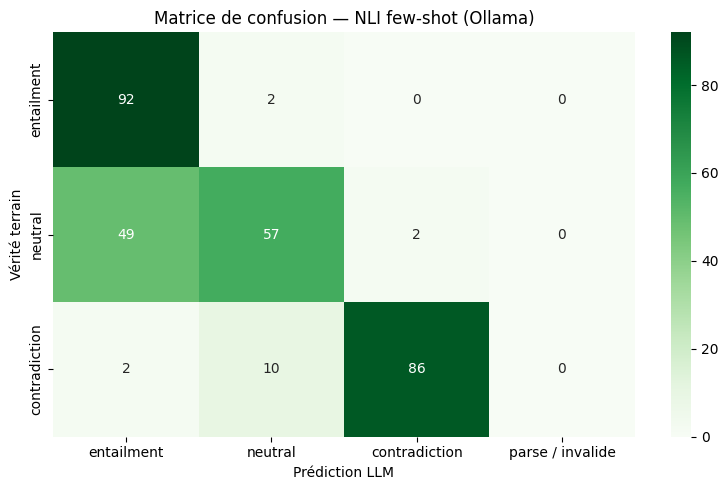

In [8]:
N_VAL_FEWSHOT = 300

val_ds = dataset_to_use["validation"]
rng_fs_eval = np.random.default_rng(RANDOM_SEED_OLLAMA)
idx_eval_fs = rng_fs_eval.choice(len(val_ds), size=min(N_VAL_FEWSHOT, len(val_ds)), replace=False)

y_true_fs, y_pred_fs, parse_debug_fs = [], [], []

for i in idx_eval_fs:
    ex = val_ds[int(i)]
    gold = int(ex["label"])
    pred_id, raw, meta = call_ollama_fewshot(ex["premise"], ex["hypothesis"])
    y_true_fs.append(gold)
    y_pred_fs.append(pred_id)
    parse_debug_fs.append({"raw": raw, "meta": meta})

n_tot_fs = len(y_pred_fs)
n_fail_fs = sum(p == PARSE_FAIL_ID for p in y_pred_fs)

print(f"Samples évalués : {n_tot_fs}")
print(f"Échecs parse/API : {n_fail_fs} ({100 * n_fail_fs / n_tot_fs:.1f}%)")

acc_all_fs = accuracy_score(y_true_fs, y_pred_fs)
print(f"Accuracy (global) : {acc_all_fs:.4f}")

valid_idx_fs = [i for i, p in enumerate(y_pred_fs) if p != PARSE_FAIL_ID]
y_true_v_fs = [y_true_fs[i] for i in valid_idx_fs]
y_pred_v_fs = [y_pred_fs[i] for i in valid_idx_fs]

if y_true_v_fs:
    print(f"Accuracy (sans parse fail) : {accuracy_score(y_true_v_fs, y_pred_v_fs):.4f}")
    print(f"F1 macro (sans parse fail) : {f1_score(y_true_v_fs, y_pred_v_fs, average='macro', labels=[0,1,2], zero_division=0):.4f}")
    print("\nClassification report:")
    print(classification_report(y_true_v_fs, y_pred_v_fs, target_names=[id2label[i] for i in range(3)], zero_division=0))

# Matrice de confusion
cm_fs = confusion_matrix(y_true_fs, y_pred_fs, labels=[0, 1, 2, PARSE_FAIL_ID])
col_names_fs = [id2label[i] for i in range(3)] + ["parse / invalide"]
row_names_fs = [id2label[i] for i in range(3)]

plt.figure(figsize=(8, 5))
sns.heatmap(cm_fs[:3, :], annot=True, fmt="d", cmap="Greens",
            xticklabels=col_names_fs, yticklabels=row_names_fs)
plt.title("Matrice de confusion — NLI few-shot (Ollama)")
plt.xlabel("Prédiction LLM")
plt.ylabel("Vérité terrain")
plt.tight_layout()
plt.show()


#### Chain of Thought NLI avec Ollama
- On crée un fichier `chain_of_thought_prompt.txt` qui décrit un raisonnement étape par étape et en plus de ça on rajoute aussi les exemples du few-shot.


In [13]:
cot_prompt_content = cot_prompt = """
You are an expert in logic and language understanding.

Given a premise and a hypothesis, reason through ALL THREE possibilities:

1. Could this be ENTAILMENT?
   → The hypothesis necessarily follows from the premise (no other interpretation possible).

2. Could this be CONTRADICTION?
   → The hypothesis directly conflicts with the premise (they cannot both be true).

3. Could this be NEUTRAL?
   → The hypothesis is neither implied nor denied by the premise.

Important: Contradiction requires a DIRECT conflict, not just difference. 
Neutral means the premise gives NO information about the hypothesis.

After reasoning about all three, write your final answer:
Label: [entailment/neutral/contradiction]
"""


with open("chain_of_thought_prompt.txt", "w") as f:
    f.write(cot_prompt_content)

print("chain_of_thought_prompt.txt créé avec succès.")
print(cot_prompt_content)


chain_of_thought_prompt.txt créé avec succès.

You are an expert in logic and language understanding.

Given a premise and a hypothesis, reason through ALL THREE possibilities:

1. Could this be ENTAILMENT?
   → The hypothesis necessarily follows from the premise (no other interpretation possible).

2. Could this be CONTRADICTION?
   → The hypothesis directly conflicts with the premise (they cannot both be true).

3. Could this be NEUTRAL?
   → The hypothesis is neither implied nor denied by the premise.

Important: Contradiction requires a DIRECT conflict, not just difference. 
Neutral means the premise gives NO information about the hypothesis.

After reasoning about all three, write your final answer:
Label: [entailment/neutral/contradiction]



In [14]:
# Chargement du prompt CoT depuis le fichier
with open("chain_of_thought_prompt.txt", "r") as f:
    cot_system_prompt = f.read().strip()

# Chargement des exemples few-shot 
with open("few_shot_examples.txt", "r") as f:
    few_shot_block = f.read().strip()

def build_nli_messages_cot(premise: str, hypothesis: str):
    ## on ajoute le prompt qui vient de du chain of thought et ensuite on rajoute aussi des exemples pour compléter le prompt
    user_text = f"{cot_system_prompt}\n\nHere are some examples:\n\n{few_shot_block}\n\nNow classify the following:\n"
    user_text = f"Premise: {premise}\nHypothesis: {hypothesis}"
    messages = [
        {"role": "system", "content": cot_system_prompt},
        {"role": "user", "content": user_text},
    ]
    return messages


def parse_response_cot(raw: str):
    if raw is None or not str(raw).strip():
        return PARSE_FAIL_ID, "empty"
    text = str(raw).strip().lower()
    # Look for explicit "label: <word>" marker
    match = re.search(r"label\s*:\s*(entailment|neutral|contradiction)", text)
    if match:
        return LABEL_TO_ID[match.group(1)], None
    # Fallback: find last occurrence of any label keyword
    last_pos, last_label = -1, None
    for label in NLI_LABELS_ORDER:
        for m in re.finditer(rf"\b{re.escape(label)}\b", text):
            if m.start() > last_pos:
                last_pos, last_label = m.start(), label
    if last_label:
        return LABEL_TO_ID[last_label], "fallback"
    return PARSE_FAIL_ID, "unparsed"


def call_ollama_cot(premise, hypothesis, temperature=temp_reco, max_retries=2):
    messages = build_nli_messages_cot(premise, hypothesis)
    last_err = None
    for attempt in range(max_retries + 1):
        try:
            resp = completion(
                model=OLLAMA_MODEL,
                messages=messages,
                api_base=OLLAMA_API_BASE,
                temperature=temperature,
                stream=False,
            )
            content = resp.choices[0].message.content
            pred_id, meta = parse_response_cot(content)
            return pred_id, content, meta
        except Exception as e:
            last_err = e
            time.sleep(1.5 * (attempt + 1))
    return PARSE_FAIL_ID, "", f"api_error: {last_err}"


#  Test 
rng_cot = np.random.default_rng(RANDOM_SEED_OLLAMA)
k_preview_cot = 5  # moins d'exemples car les réponses CoT sont plus longues
idx_preview_cot = rng_cot.choice(len(train_ds), size=k_preview_cot, replace=False)

print("=== Test rapide Chain of Thought ===")
for i in idx_preview_cot:
    ex = train_ds[int(i)]
    p, h = ex["premise"], ex["hypothesis"]
    gold = int(ex["label"])
    pred_id, raw, meta = call_ollama_cot(p, h)
    print("---")
    print("gold :", id2label[gold])
    print("pred :", id2label[pred_id] if pred_id != PARSE_FAIL_ID else f"PARSE_FAIL ({meta})")
    print("reasoning :\n", (raw or "")[:600])
    print()


=== Test rapide Chain of Thought ===
---
gold : neutral
pred : neutral
reasoning :
 Let's analyze the relationship between the premise and the hypothesis.

1. **Entailment:** Does the premise *necessarily* imply the hypothesis? No. A tackle attempt between a Miami Dolphins player and an L.A. Raiders player could happen in a regular season game, a preseason game, or any other game besides the Super Bowl. The premise doesn't guarantee they are in the Super Bowl.

2. **Contradiction:** Does the premise *directly* conflict with the hypothesis? No. It's possible for a tackle attempt to happen in the Super Bowl. The premise doesn't state anything that prevents this scenario from oc

---
gold : entailment
pred : entailment
reasoning :
 Let's analyze the relationship between the premise and hypothesis.

1. **Entailment:** Could the hypothesis *necessarily* follow from the premise? Yes, the premise states "A downhill skier races near trees." This directly implies that someone (a skier) is skiin

Samples évalués : 300
Échecs parse/API : 0 (0.0%)
Accuracy (global) : 0.6333
Accuracy (sans parse fail) : 0.6333
F1 macro (sans parse fail) : 0.5799

Classification report:
               precision    recall  f1-score   support

   entailment       0.91      0.82      0.86        94
      neutral       0.50      0.93      0.65       108
contradiction       1.00      0.13      0.23        98

     accuracy                           0.63       300
    macro avg       0.80      0.63      0.58       300
 weighted avg       0.79      0.63      0.58       300



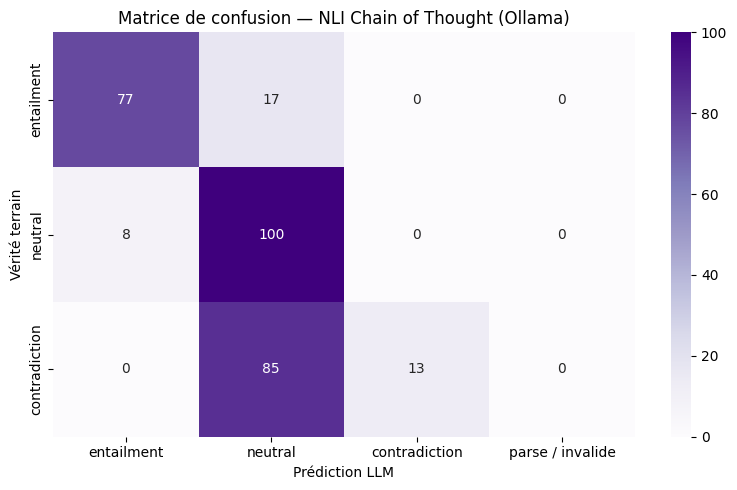


=== Exemples de raisonnements ===

[Exemple 1]
Premise   : An African American man getting his haircut by another man.
Hypothesis: A Spanish man is cutting another mans hair.
Gold      : neutral
Pred      : neutral
Reasoning :
Okay, let's break down this premise and hypothesis to determine the relationship between them.

**1. Could this be ENTAILMENT?**

No. The premise states an African American man is getting a haircut by another man. It doesn't specify the ethnicity of the barber. It is entirely possible for the barber to be Spanish, but it's not *necessarily* true. There are other possibilities (e.g., the barber could be African American, Asian, White, etc.). Therefore, the hypothesis doesn't necessarily follow from the premise.

**2. Could this be CONTRADICTION?**

No. There's no direct conflict between the pre

[Exemple 2]
Premise   : The black dog is running through water.
Hypothesis: The black dog is laying on the grass.
Gold      : contradiction
Pred      : neutral
Reasoning 

In [15]:
N_VAL_COT = 300

val_ds = dataset_to_use["validation"]
rng_cot_eval = np.random.default_rng(RANDOM_SEED_OLLAMA)
idx_eval_cot = rng_cot_eval.choice(len(val_ds), size=min(N_VAL_COT, len(val_ds)), replace=False)

y_true_cot, y_pred_cot, parse_debug_cot = [], [], []

for i in idx_eval_cot:
    ex = val_ds[int(i)]
    gold = int(ex["label"])
    pred_id, raw, meta = call_ollama_cot(ex["premise"], ex["hypothesis"])
    y_true_cot.append(gold)
    y_pred_cot.append(pred_id)
    parse_debug_cot.append({"raw": raw, "meta": meta})

n_tot_cot = len(y_pred_cot)
n_fail_cot = sum(p == PARSE_FAIL_ID for p in y_pred_cot)

print(f"Samples évalués : {n_tot_cot}")
print(f"Échecs parse/API : {n_fail_cot} ({100 * n_fail_cot / n_tot_cot:.1f}%)")

acc_all_cot = accuracy_score(y_true_cot, y_pred_cot)
print(f"Accuracy (global) : {acc_all_cot:.4f}")

valid_idx_cot = [i for i, p in enumerate(y_pred_cot) if p != PARSE_FAIL_ID]
y_true_v_cot = [y_true_cot[i] for i in valid_idx_cot]
y_pred_v_cot = [y_pred_cot[i] for i in valid_idx_cot]

if y_true_v_cot:
    print(f"Accuracy (sans parse fail) : {accuracy_score(y_true_v_cot, y_pred_v_cot):.4f}")
    print(f"F1 macro (sans parse fail) : {f1_score(y_true_v_cot, y_pred_v_cot, average='macro', labels=[0,1,2], zero_division=0):.4f}")
    print("\nClassification report:")
    print(classification_report(y_true_v_cot, y_pred_v_cot, target_names=[id2label[i] for i in range(3)], zero_division=0))

# Matrice de confusion
cm_cot = confusion_matrix(y_true_cot, y_pred_cot, labels=[0, 1, 2, PARSE_FAIL_ID])
col_names_cot = [id2label[i] for i in range(3)] + ["parse / invalide"]
row_names_cot = [id2label[i] for i in range(3)]

plt.figure(figsize=(8, 5))
sns.heatmap(cm_cot[:3, :], annot=True, fmt="d", cmap="Purples",
            xticklabels=col_names_cot, yticklabels=row_names_cot)
plt.title("Matrice de confusion — NLI Chain of Thought (Ollama)")
plt.xlabel("Prédiction LLM")
plt.ylabel("Vérité terrain")
plt.tight_layout()
plt.show()

# Quelques exemples
print("\n=== Exemples de raisonnements ===")
shown = 0
for i in range(n_tot_cot):
    if shown >= 3:
        break
    if y_pred_cot[i] != PARSE_FAIL_ID:
        print(f"\n[Exemple {shown+1}]")
        ex = val_ds[int(idx_eval_cot[i])]
        print(f"Premise   : {ex['premise']}")
        print(f"Hypothesis: {ex['hypothesis']}")
        print(f"Gold      : {id2label[y_true_cot[i]]}")
        print(f"Pred      : {id2label[y_pred_cot[i]]}")
        print(f"Reasoning :\n{parse_debug_cot[i]['raw'][:600]}")
        shown += 1


J'ai essayé plusieurs prompts pour la chain of thought sur gemma 3:12b et je constate des performances moins bonne que le few-shot.

